<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from google.colab import userdata

In [3]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

##**DATA PREPARATION**

In [4]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:06<00:00, 15.7MB/s]



In [5]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 0
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 0
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 0
Validation data path: cardetection_dataset/car/valid/labels
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [6]:
import yaml

In [7]:
yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [8]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [10]:
train_images_dir = "cardetection_dataset/car/train/images"
train_labels_dir = "cardetection_dataset/car/train/labels"

if os.path.exists(train_images_dir) and os.path.exists(train_labels_dir):
    image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:
        random_image = random.choice(image_files)
        corresponding_label = os.path.splitext(random_image)[0] + '.txt'

        print(f"Image File: {random_image}")
        print(f"Label File: {corresponding_label}")

        # Verify if the label file actually exists
        if os.path.exists(os.path.join(train_labels_dir, corresponding_label)):
            print("Status: Corresponding label file exists!")
        else:
            print("Status: Corresponding label file is missing.")

Image File: 000545_jpg.rf.fea2d51fb2f69f9443066e69237f53d0.jpg
Label File: 000545_jpg.rf.fea2d51fb2f69f9443066e69237f53d0.txt
Status: Corresponding label file exists!


In [11]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [12]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

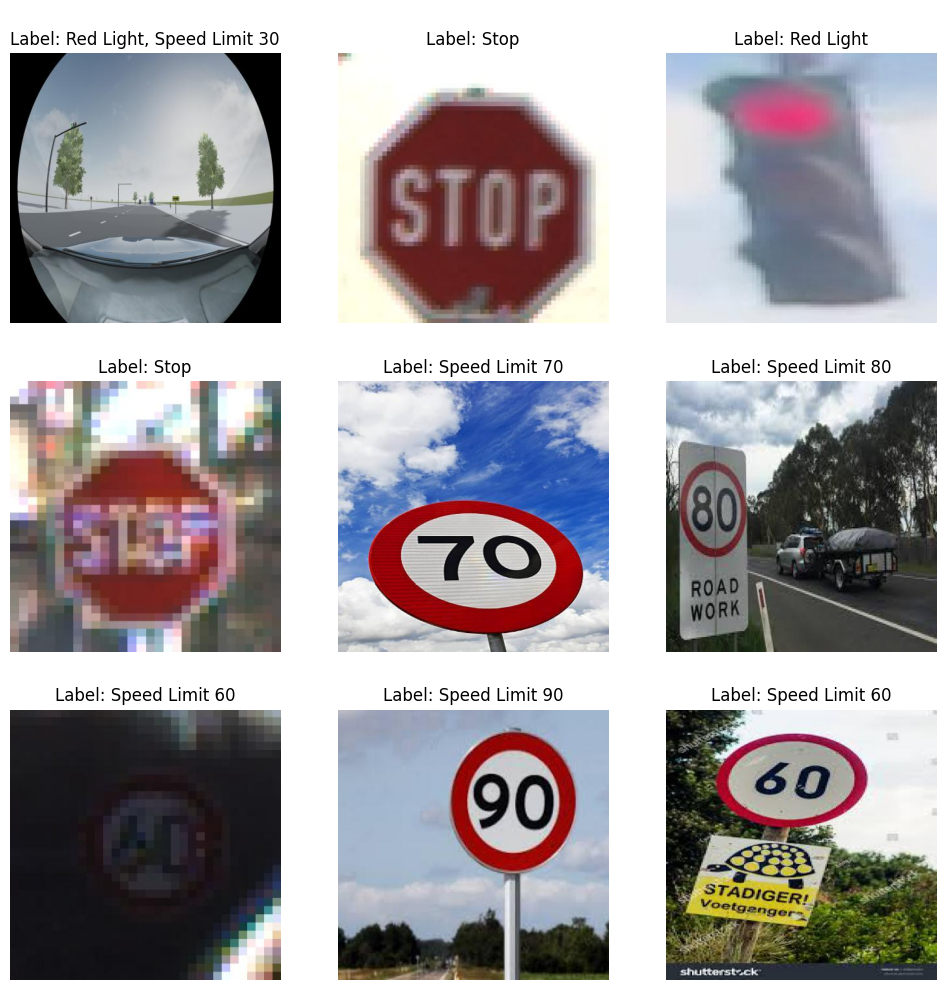

In [13]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

##**DATA PREPROCESSING**

In [14]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import numpy as np

In [15]:
# Function for applying reproducibility globally
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [16]:
class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        class_labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_labels.append(int(data[0]))
                        # YOLO format: [x_center, y_center, width, height]
                        boxes.append([float(x) for x in data[1:5]])

        # Load image using OpenCV (returns BGR) and convert to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply Albumentations transformations
        if self.transform:
            augmentations = self.transform(image=image, bboxes=boxes, class_labels=class_labels)
            image = augmentations['image']
            boxes = augmentations['bboxes']
            class_labels = augmentations['class_labels']

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box, class_label in zip(boxes, class_labels):
            class_label = int(class_label)
            x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            if label_matrix[i, j, self.C] == 0:
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                label_matrix[i, j, class_label] = 1

        return image, label_matrix


In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [18]:
# Define execution parameters
GRID_SIZE = 7
BBOXES = 2
CLASSES = len(class_names)
BATCH_SIZE = 32
NUM_WORKERS = 2

# Define Albumentations transformations
train_transform_pipeline = A.Compose([
    A.Resize(height=416, width=416),
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=0, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussianBlur(blur_limit=(5, 9), sigma_limit=(0.1, 5.), p=0.5),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

val_transform_pipeline = A.Compose([
    A.Resize(height=416, width=416),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=train_transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=val_transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=val_transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


##**MODEL BUILDING**

In [19]:
import torch.nn as nn

In [20]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class TrafficSignDetector(nn.Module):
    def __init__(self, in_channels=3, S=7, B=2, C=15):
        super(TrafficSignDetector, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        self.features = nn.Sequential(
            CNNBlock(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(192, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),

            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, stride=2, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1)
        )

        # Fully convolutional head to replace linear layers
        self.head = nn.Conv2d(1024, self.C + self.B * 5, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)

        # Reshape to match DataLoader target tensor format
        # Permute from (Batch, Channels, S, S) to (Batch, S, S, Channels)
        x = x.permute(0, 2, 3, 1)
        return x


In [21]:
model = TrafficSignDetector(in_channels=3, S=GRID_SIZE, B=BBOXES, C=CLASSES)

In [22]:
!pip install torchinfo

In [23]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─CNNBlock: 2-1                     --
│    │    └─Conv2d: 3-1                  9,408
│    │    └─BatchNorm2d: 3-2             128
│    │    └─LeakyReLU: 3-3               --
│    └─MaxPool2d: 2-2                    --
│    └─CNNBlock: 2-3                     --
│    │    └─Conv2d: 3-4                  110,592
│    │    └─BatchNorm2d: 3-5             384
│    │    └─LeakyReLU: 3-6               --
│    └─MaxPool2d: 2-4                    --
│    └─CNNBlock: 2-5                     --
│    │    └─Conv2d: 3-7                  24,576
│    │    └─BatchNorm2d: 3-8             256
│    │    └─LeakyReLU: 3-9               --
│    └─CNNBlock: 2-6                     --
│    │    └─Conv2d: 3-10                 294,912
│    │    └─BatchNorm2d: 3-11            512
│    │    └─LeakyReLU: 3-12              --
│    └─CNNBlock: 2-7                     --
│    │

In [24]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

##**MODEL TRAINING**

In [26]:
import torch.optim as optim

In [27]:
# The main loss function to use, focusing on classification
cross_entropy_loss = nn.CrossEntropyLoss(reduction="sum")

# The additional loss function for training and predicting where the bounding boxes are
mse_loss = nn.MSELoss(reduction="sum")


# Still need the model to actively know where the objects are
def loss_fn(predictions, targets):
    C = 15
    B = 2
    S = 7

    predictions = predictions.reshape(-1, S, S, C + B * 5)
    targets = targets.reshape(-1, S, S, C + B * 5)

    # Masks for grid cells that contain an object vs no object
    obj_mask = targets[..., C] == 1
    noobj_mask = targets[..., C] == 0

    # CLASSIFICATION LOSS (Cross entropy)
    pred_class = predictions[..., :C][obj_mask]
    target_class_idx = targets[..., :C][obj_mask].argmax(dim=-1)

    if len(pred_class) > 0:
        class_loss = cross_entropy_loss(pred_class, target_class_idx)
    else:
        class_loss = torch.tensor(0.0, device=predictions.device)

    # BOUNDING BOX & CONFIDENCE LOSS (MSE)
    # Box 1 data
    pred_conf1 = predictions[..., C]
    pred_box1 = predictions[..., C+1:C+5]

    # Box 2 data
    pred_conf2 = predictions[..., C+5]
    pred_box2 = predictions[..., C+6:C+10]

    # Target data
    target_conf = targets[..., C]
    target_box = targets[..., C+1:C+5]

    # Confidence loss (Object exists)
    conf_loss_obj = mse_loss(pred_conf1[obj_mask], target_conf[obj_mask]) + \
                    mse_loss(pred_conf2[obj_mask], target_conf[obj_mask])

    # Confidence loss (No object exists - penalize false positives)
    conf_loss_noobj = mse_loss(pred_conf1[noobj_mask], target_conf[noobj_mask]) + \
                      mse_loss(pred_conf2[noobj_mask], target_conf[noobj_mask])

    # Box Coordinates loss (Only calculate where object exists)
    box_loss = mse_loss(pred_box1[obj_mask], target_box[obj_mask]) + \
               mse_loss(pred_box2[obj_mask], target_box[obj_mask])

    lambda_coord = 5.0
    lambda_noobj = 0.5

    total_loss = class_loss + (lambda_coord * box_loss) + conf_loss_obj + (lambda_noobj * conf_loss_noobj)

    # Return bothj average total loss AND pure crossentropy loss per batch
    batch_size = predictions.shape[0]
    return total_loss / batch_size, class_loss / batch_size

In [29]:
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image

In [30]:
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

model.to(device)

# Initialize GradScaler for mixed precision training
scaler = torch.cuda.amp.GradScaler()

def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []
    mean_cls_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)

        with torch.cuda.amp.autocast():
            out = model(x)
            loss, cls_loss = loss_fn(out, y)

        mean_loss.append(loss.item())
        mean_cls_loss.append(cls_loss.item())
        optimizer.zero_grad()

        # Backward pass with scaled loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    return sum(mean_loss) / len(mean_loss), sum(mean_cls_loss) / len(mean_cls_loss)

def val_fn(val_loader, model, loss_fn):
    loop = tqdm(val_loader, leave=True)
    mean_loss = []
    mean_cls_loss = []

    with torch.inference_mode():
        for batch_idx, (x, y) in enumerate(loop):
            x, y = x.to(device), y.to(device)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss, cls_loss = loss_fn(out, y)

            mean_loss.append(loss.item())
            mean_cls_loss.append(cls_loss.item())
            loop.set_postfix(val_loss=loss.item())

    return sum(mean_loss) / len(mean_loss), sum(mean_cls_loss) / len(mean_cls_loss)

epochs = 150
epoch_count = []
loss_values = []
val_loss_values = []
class_loss_values = []
val_class_loss_values = []

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Starting training on {device}...")
for epoch in range(epochs):
    print(f"\nEpoch: {epoch+1}/{epochs}")

    # Training
    model.train()
    avg_loss, avg_cls_loss = train_fn(train_loader, model, optimizer, loss_fn)

    # Validation
    model.eval()
    avg_val_loss, avg_val_cls_loss = val_fn(val_loader, model, loss_fn)

    # Step the scheduler based on the validation loss
    scheduler.step(avg_val_loss)

    epoch_count.append(epoch + 1)
    loss_values.append(avg_loss)
    val_loss_values.append(avg_val_loss)
    class_loss_values.append(avg_cls_loss)
    val_class_loss_values.append(avg_val_cls_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train CE: {avg_cls_loss:.4f} | Val CE: {avg_val_cls_loss:.4f}")

/tmp/ipykernel_6555/2903493122.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting training on cuda...

Epoch: 1/150


  0%|          | 0/110 [00:00<?, ?it/s]/tmp/ipykernel_6555/2903493122.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/26 [00:00<?, ?it/s]/tmp/ipykernel_6555/2903493122.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 26/26 [00:02<00:00,  9.74it/s, val_loss=7.93]


Epoch 1 Train Loss: 59.7415 | Val Loss: 24.8271 | Train CE: 2.9948 | Val CE: 2.6743

Epoch: 2/150


100%|██████████| 26/26 [00:02<00:00, 10.18it/s, val_loss=7.56]


...

Epoch 148 Train Loss: 0.3632 | Val Loss: 1.2572 | Train CE: 0.0507 | Val CE: 0.3239

Epoch: 149/150


100%|██████████| 26/26 [00:02<00:00, 10.06it/s, val_loss=0.0149]


Epoch 149 Train Loss: 0.3714 | Val Loss: 1.2790 | Train CE: 0.0545 | Val CE: 0.3235

Epoch: 150/150


100%|██████████| 26/26 [00:02<00:00, 10.11it/s, val_loss=0.014]

Epoch 150 Train Loss: 0.3476 | Val Loss: 1.2841 | Train CE: 0.0494 | Val CE: 0.3232


##**MODEL TESTING**

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision.ops import box_convert

In [52]:
# Gather predicted and actual values
def get_predictions(model, dataloader, device, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            predictions = logits.reshape(-1, S, S, C + B * 5)
            targets = targets.reshape(-1, S, S, C + B * 5)

            for b in range(batch_size):
                pred = predictions[b]

                # Get classes, confidences, and boxes
                pred_classes = torch.argmax(pred[..., :C], dim=-1)

                # Extract boxes and confidences
                conf1 = pred[..., C:C+1]
                box1 = pred[..., C+1:C+5]
                conf2 = pred[..., C+5:C+6]
                box2 = pred[..., C+6:C+10]

                # Choose the box with the highest confidence for each grid cell
                conf_mask = conf1 > conf2
                best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
                best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

                # Filter by confidence threshold
                mask = best_conf > conf_threshold

                filtered_boxes = best_box[mask]
                filtered_scores = best_conf[mask]
                filtered_classes = pred_classes[mask]

                if filtered_boxes.shape[0] > 0:
                    pred_boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    pred_boxes_xyxy = torch.empty((0, 4), device=device)

                all_preds.append({
                    'boxes': pred_boxes_xyxy,
                    'scores': filtered_scores,
                    'labels': filtered_classes
                })

                target = targets[b]

                target_conf = target[..., C]
                target_classes = torch.argmax(target[..., :C], dim=-1)
                target_boxes = target[..., C+1:C+5]

                obj_mask = target_conf == 1

                t_boxes = target_boxes[obj_mask]
                t_labels = target_classes[obj_mask]

                if t_boxes.shape[0] > 0:
                    target_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    target_boxes_xyxy = torch.empty((0, 4), device=device)

                all_targets.append({
                    'boxes': target_boxes_xyxy,
                    'labels': t_labels
                })

    return all_preds, all_targets


In [54]:
train_labels, train_preds = get_predictions(model, train_loader, device)
test_labels, test_preds = get_predictions(model, test_loader, device)

##**MODEL EVALUATION**

In [55]:
!pip install -q torchmetrics

In [56]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [57]:
def evaluate_model(model, dataloader, device):
    print("Evaluating model...")
    map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    # Get predictions and targets in the torchmetrics format
    preds, targets = get_predictions(model, dataloader, device)

    map_metric.update(preds, targets)
    map_results = map_metric.compute()

    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")
    print(f"mAP (IoU=0.50): {map_results['map_50']:.4f}")
    print(f"mAP (IoU=0.75): {map_results['map_75']:.4f}")

    return map_results['map']

test_map = evaluate_model(model, test_loader, device)

Evaluating model...
mAP (IoU=0.50:0.95): 0.5183
mAP (IoU=0.50): 0.6936
mAP (IoU=0.75): 0.5436


##**EXPERIMENTS OF THE CUSTOM MODEL**

In [38]:
import pandas as pd
from IPython.display import display

In [39]:
experiments_data = {
    "Experiment Number": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Experiment Description": [
        "Baseline",
        "Increased batch size to 16",
        "Increased batch size to 32",
        "Increased batch size to 64",
        "Increased epoch to 100",
        "32 batch size and 100 epoch",
        "Reduced the number of convolutional layers",
        "24 convolutional layers and completely removed the linear layers",
        "Changed the learning rate to 2e-5",
        "Added ColorJitter, GaussianBlur, and random scaling augmentations",
        "Increased epoch to 150"
    ],
    "EPOCH": [
        50,
        50,
        50,
        50,
        100,
        100,
        100,
        100,
        100,
        100,
        150
    ],
    "BATCH_SIZE": [
        8,
        16,
        32,
        64,
        64,
        32,
        32,
        32,
        32,
        32,
        32
    ],
    "LEARNING_RATE": [
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.00002,
        0.0001,
        0.0001
    ],
    "# of Parameters": [
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "21,070,025",
        "60,194,777",
        "60,194,777",
        "60,194,777",
        "60,194,777"
    ],
    "Evaluation Score (mAP)": [
        0.2869,
        0.2872,
        0.2812,
        0.2675,
        0.2762,
        0.2946,
        0.2946,
        0.4129,
        0.2910,
        0.4749,
        0.5353
    ]
}

experiments_df = pd.DataFrame(experiments_data)
display(experiments_df)

,Experiment Number,Experiment Description,EPOCH,BATCH_SIZE,LEARNING_RATE,# of Parameters,Evaluation Score (mAP)
0,1,Baseline,50,8,0.00010,"85,665,769",0.2869
1,2,Increased batch size to 16,50,16,0.00010,"85,665,769",0.2872
2,3,Increased batch size to 32,50,32,0.00010,"85,665,769",0.2812
3,4,Increased batch size to 64,50,64,0.00010,"85,665,769",0.2675
4,5,Increased epoch to 100,100,64,0.00010,"85,665,769",0.2762
5,6,32 batch size and 100 epoch,100,32,0.00010,"85,665,769",0.2946
6,7,Reduced the number of convolutional layers,100,32,0.00010,"21,070,025",0.2946
7,8,24 convolutional layers and completely removed...,100,32,0.00010,"60,194,777",0.4129
8,9,Changed the learning rate to 2e-5,100,32,0.00002,"60,194,777",0.2910
9,10,"Added ColorJitter, GaussianBlur, and random sc...",100,32,0.00010,"60,194,777",0.4749


##**VISUALIZATION OF RESULTS**

In [40]:
from sklearn.metrics import confusion_matrix

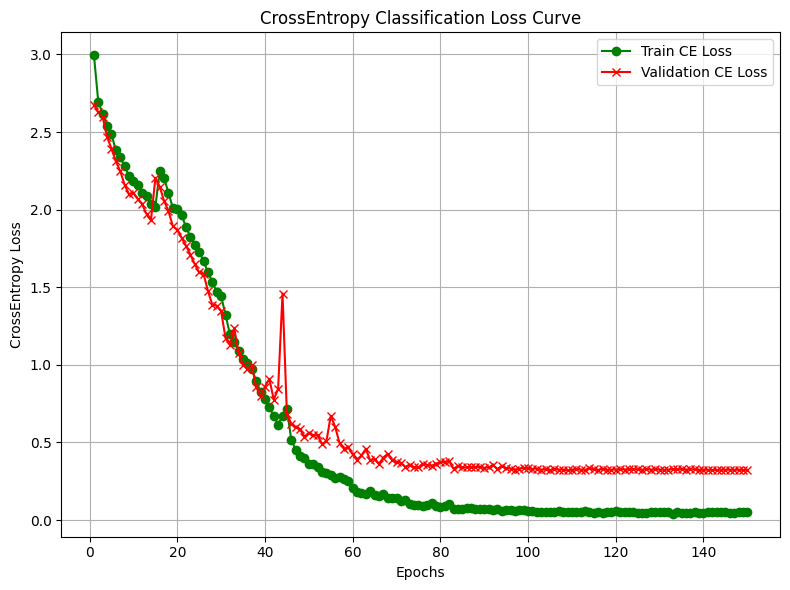

In [41]:
plt.figure(figsize=(8, 6))

# Plot pure crossentropy classification loss
plt.plot(epoch_count, class_loss_values, label="Train CE Loss", color="green", marker="o")
plt.plot(epoch_count, val_class_loss_values, label="Validation CE Loss", color="red", marker="x")
plt.title("CrossEntropy Classification Loss Curve")
plt.ylabel("CrossEntropy Loss")
plt.xlabel("Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision.ops import box_iou
import numpy as np

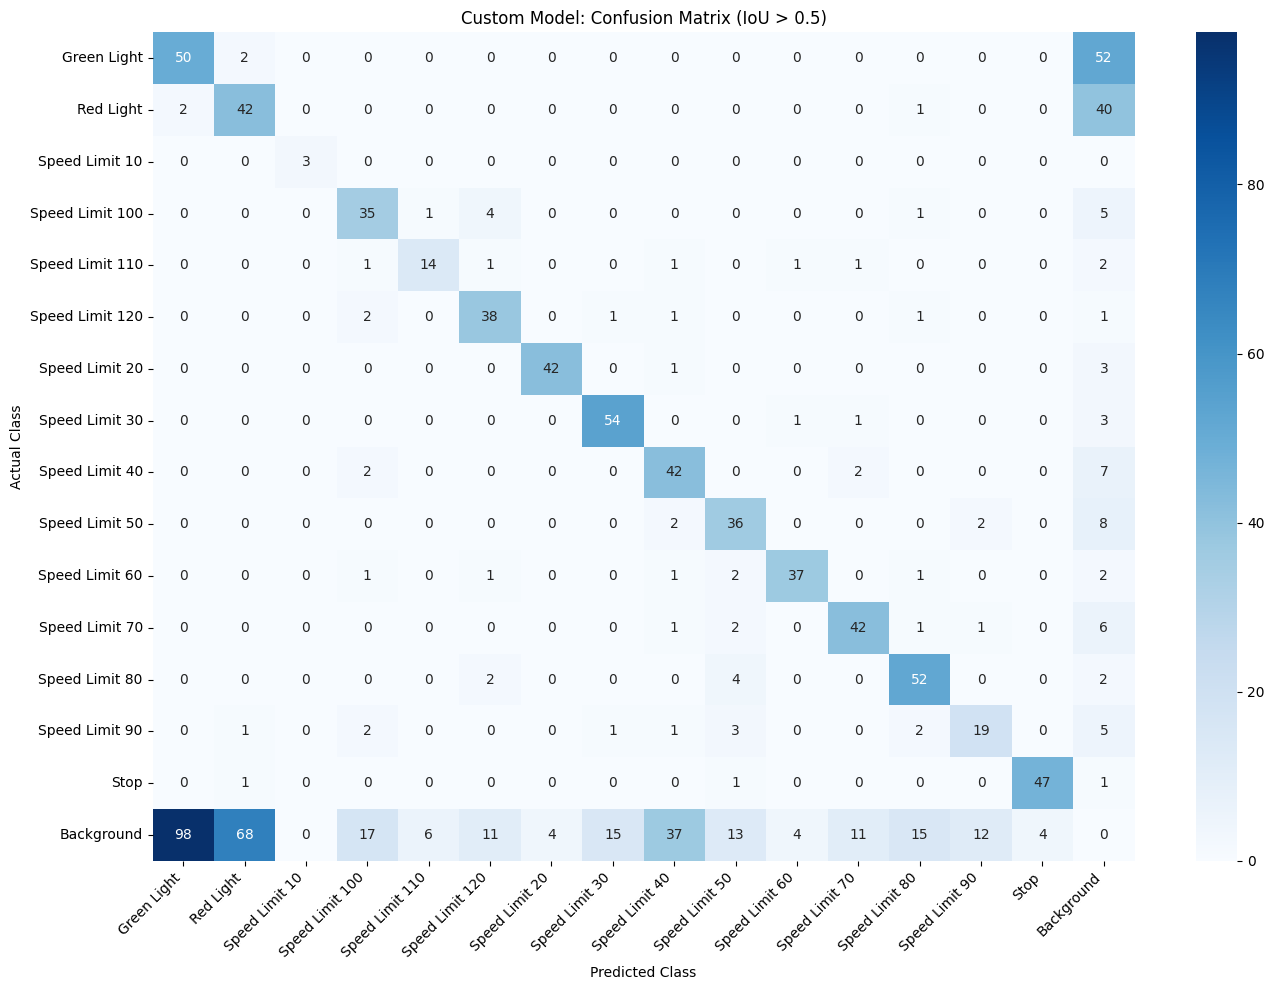

In [45]:
# Get predictions from the test set
preds, targets = get_predictions(model, test_loader, device)

y_true = []
y_pred = []
background_class = 15

# Match predictions to ground truth targets to build the confusion matrix lists
for i in range(len(targets)):
    t_boxes = targets[i]['boxes']
    t_labels = targets[i]['labels']
    p_boxes = preds[i]['boxes']
    p_labels = preds[i]['labels']

    if len(t_boxes) == 0 and len(p_boxes) == 0:
        continue
    elif len(t_boxes) == 0:
        # All predictions are False Positives (Background truth)
        y_pred.extend(p_labels.cpu().numpy())
        y_true.extend([background_class] * len(p_boxes))
        continue
    elif len(p_boxes) == 0:
        # All targets are False Negatives (Background predicted)
        y_true.extend(t_labels.cpu().numpy())
        y_pred.extend([background_class] * len(t_boxes))
        continue

    # Compute IoU between target and predicted boxes
    ious = box_iou(t_boxes, p_boxes)

    matched_preds = set()
    for t_idx, t_label in enumerate(t_labels):
        best_iou, p_idx = ious[t_idx].max(dim=0)
        if best_iou > 0.5:
            # True Positive or Misclassification
            y_true.append(t_label.item())
            y_pred.append(p_labels[p_idx].item())
            matched_preds.add(p_idx.item())
        else:
            # False Negative (Missed object)
            y_true.append(t_label.item())
            y_pred.append(background_class)

    # Any predictions not matched to a target are False Positives
    for p_idx, p_label in enumerate(p_labels):
        if p_idx not in matched_preds:
            y_pred.append(p_label.item())
            y_true.append(background_class)

# Extend class names with the Background class
ext_class_names = class_names + ["Background"]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(CLASSES + 1))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ext_class_names, yticklabels=ext_class_names)
plt.title('Custom Model: Confusion Matrix (IoU > 0.5)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [46]:
def plot_predicted_image(img_path, model, device, transform, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        logits = model(img_tensor)

    pred = logits.reshape(-1, S, S, C + B * 5)[0]

    pred_classes = torch.argmax(pred[..., :C], dim=-1)
    conf1 = pred[..., C:C+1]
    box1 = pred[..., C+1:C+5]
    conf2 = pred[..., C+5:C+6]
    box2 = pred[..., C+6:C+10]

    conf_mask = conf1 > conf2
    best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
    best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

    mask = best_conf > conf_threshold
    filtered_classes = pred_classes[mask]
    filtered_scores = best_conf[mask]

    fig, ax = plt.subplots(1, figsize=(8, 8))
    # Resize image to model input size for plotting
    img_np = np.array(img.resize((448, 448)))  # Updated to match the potential 448x448 resize
    ax.imshow(img_np)
    ax.axis("off")

    # Hide bounding boxes, just show the classification results
    detected_objects = []
    for cls, score in zip(filtered_classes, filtered_scores):
        class_name = class_names[cls.item()]
        detected_objects.append(f"{class_name} ({score:.2f})")

    if detected_objects:
        title_text = "Classification Results: \n" + " | ".join(detected_objects)
    else:
        title_text = "Classification Results: No Traffic Signs Detected"

    plt.title(title_text, fontsize=12, pad=15, weight='bold')
    plt.tight_layout()
    plt.show()


In [47]:
from PIL import Image
import glob
import random
import numpy as np

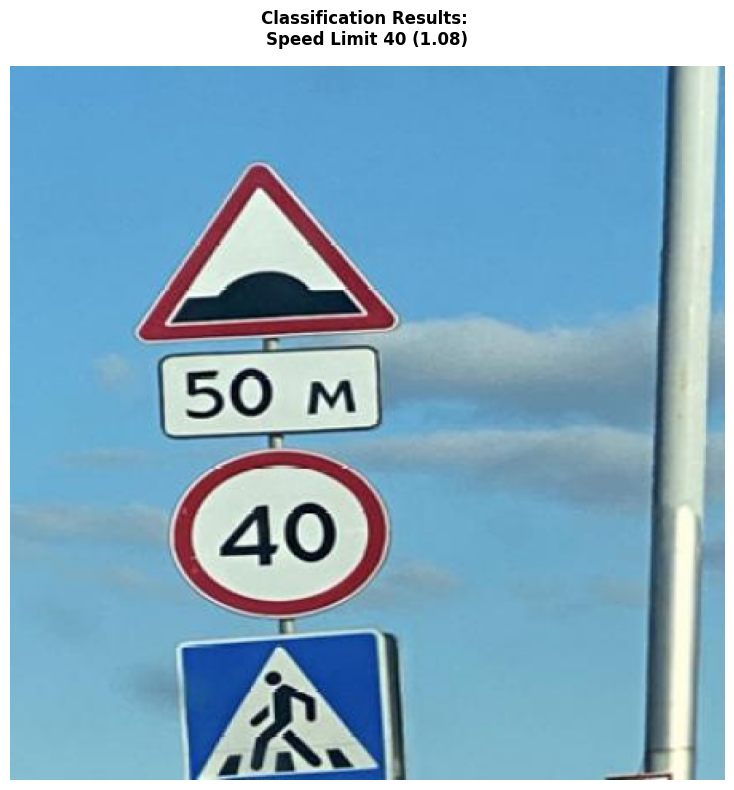

In [49]:
test_images = glob.glob("cardetection_dataset/car/test/images/*.jpg")
if test_images:
    random_test_img = random.choice(test_images)

    # Create a wrapper for Albumentations to work with PIL Image input
    transform_wrapper = lambda pil_img: val_transform_pipeline(
        image=np.array(pil_img),
        bboxes=[],
        class_labels=[]
    )['image']

    plot_predicted_image(random_test_img, model, device, transform_wrapper)
else:
    print("No test images found.")
